# Notebook 03: Machine Learning Modeling, Cross-Validation & Diagnostics
## University Student Performance Dataset

---

### Objectives
1. Partition dataset into 80% train / 20% test partitions using reproducible seed `42`.
2. Apply `StandardScaler` fitted strictly on training data to prevent leakage.
3. Train and compare 4 regression models:
   - **Ordinary Least Squares (OLS) Linear Regression** (baseline econometric model)
   - **Ridge Regression (L2 regularization)**
   - **Lasso Regression (L1 regularization)**
   - **Random Forest Regressor** (non-linear ensemble benchmark)
4. Conduct 5-fold cross-validation and holdout evaluation (MAE, RMSE, $R^2$, MAPE).
5. Verify residual assumptions (normality, homoscedasticity, independence).
6. Evaluate Early-Stage (Pre-Midterm) model vs Full-Semester model.
7. Save serialized model artifacts and generate test predictions.

In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import yaml

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import statsmodels.api as sm

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# Load configuration
with open('../config.yaml', 'r') as f:
    config = yaml.safe_load(f)

df = pd.read_csv('../' + config['paths']['interim'])
print(f"Loaded dataset: {df.shape[0]} samples")

Loaded dataset: 398 samples


## 1. Train/Test Partitioning & Feature Standardization

In [2]:
features = ['attendance_pct', 'study_hours_week', 'assignment_avg', 'midterm_score', 'previous_gpa']
X = df[features]
y = df['final_score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=features, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=features, index=X_test.index)

print(f"Train samples: {len(X_train)} | Test samples: {len(X_test)}")

Train samples: 318 | Test samples: 80


## 2. Multi-Model Benchmark (5-Fold Cross-Validation)

In [3]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression (alpha=1.0)': Ridge(alpha=1.0),
    'Lasso Regression (alpha=0.1)': Lasso(alpha=0.1),
    'Random Forest (n=100)': RandomForestRegressor(n_estimators=100, random_state=42)
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)
results = []

for name, model in models.items():
    cv_r2 = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='r2')
    cv_rmse = np.sqrt(-cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='neg_mean_squared_error'))
    
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    
    results.append({
        'Model': name,
        'CV R² (Mean)': round(cv_r2.mean(), 4),
        'CV RMSE (pts)': round(cv_rmse.mean(), 3),
        'Test R²': round(r2_score(y_test, preds), 4),
        'Test RMSE (pts)': round(np.sqrt(mean_squared_error(y_test, preds)), 3),
        'Test MAE (pts)': round(mean_absolute_error(y_test, preds), 3)
    })

benchmark_df = pd.DataFrame(results).sort_values('Test R²', ascending=False)
benchmark_df

,Model,CV R² (Mean),CV RMSE (pts),Test R²,Test RMSE (pts),Test MAE (pts)
0,Linear Regression,0.8815,3.971,0.9288,3.393,2.627
1,Ridge Regression (alpha=1.0),0.8816,3.970,0.9288,3.394,2.627
2,Lasso Regression (alpha=0.1),0.8815,3.971,0.9278,3.417,2.633
3,Random Forest (n=100),0.8527,4.422,0.8997,4.026,3.160


## 3. Econometric Summary & Coefficient Analysis

In [4]:
X_train_sm = sm.add_constant(X_train_scaled)
ols = sm.OLS(y_train, X_train_sm).fit()
print(ols.summary())

                            OLS Regression Results                            
Dep. Variable:            final_score   R-squared:                       0.888
Model:                            OLS   Adj. R-squared:                  0.886
Method:                 Least Squares   F-statistic:                     495.4
Date:                Thu, 08 Oct 2026   Prob (F-statistic):          4.90e-146
Time:                        22:19:12   Log-Likelihood:                -885.06
No. Observations:                 318   AIC:                             1782.
Df Residuals:                     312   BIC:                             1805.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               78.5462      0.222  

## 4. Residual Diagnostics

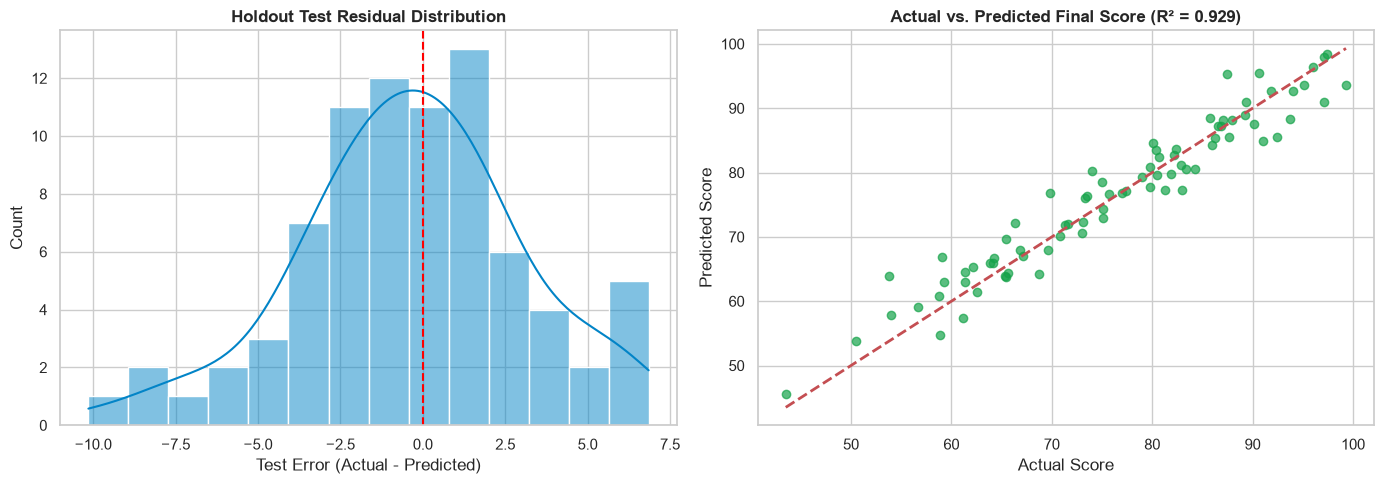

In [5]:
best_lr = LinearRegression()
best_lr.fit(X_train_scaled, y_train)
test_preds = best_lr.predict(X_test_scaled)
residuals_test = y_test - test_preds

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Residual Histogram
sns.histplot(residuals_test, kde=True, color='#0284c7', ax=ax1, bins=14)
ax1.axvline(0, color='red', linestyle='--')
ax1.set_title("Holdout Test Residual Distribution", fontweight='bold')
ax1.set_xlabel("Test Error (Actual - Predicted)")

# Actual vs Predicted
ax2.scatter(y_test, test_preds, color='#16a34a', alpha=0.7)
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
ax2.set_title(f"Actual vs. Predicted Final Score (R² = {r2_score(y_test, test_preds):.3f})", fontweight='bold')
ax2.set_xlabel("Actual Score")
ax2.set_ylabel("Predicted Score")

plt.tight_layout()
plt.show()

## 5. Early-Stage Model Comparison & Deployment
Comparing the early-stage (pre-midterm) model with the full-semester model:

In [6]:
# Pre-midterm early stage features
early_cols = ['attendance_pct', 'study_hours_week', 'previous_gpa']
early_scaler = StandardScaler()
X_tr_early = early_scaler.fit_transform(X_train[early_cols])
X_te_early = early_scaler.transform(X_test[early_cols])

early_model = LinearRegression().fit(X_tr_early, y_train)
early_preds = early_model.predict(X_te_early)

summary_table = pd.DataFrame([
    {
        'Pipeline Stage': 'Early Stage (Weeks 1-6)',
        'Predictors': 'Attendance, Study Hours, GPA',
        'Holdout R²': round(r2_score(y_test, early_preds), 4),
        'Holdout MAE': round(mean_absolute_error(y_test, early_preds), 3),
        'Application': 'Proactive At-Risk Warning'
    },
    {
        'Pipeline Stage': 'Full Semester (Weeks 8-12)',
        'Predictors': 'All 5 Indicators (including Midterm & Coursework)',
        'Holdout R²': round(r2_score(y_test, test_preds), 4),
        'Holdout MAE': round(mean_absolute_error(y_test, test_preds), 3),
        'Application': 'Final Grade Projection'
    }
])
summary_table

,Pipeline Stage,Predictors,Holdout R²,Holdout MAE,Application
0,Early Stage (Weeks 1-6),"Attendance, Study Hours, GPA",0.8963,3.231,Proactive At-Risk Warning
1,Full Semester (Weeks 8-12),All 5 Indicators (including Midterm & Coursework),0.9288,2.627,Final Grade Projection
